# 59 — Stable vs Reversing Feature Transfer Test

**Project:** AI VPN Firewall — Thesis  
**Source pipeline:** Clean Pipeline (NB41-55)  
**Hypothesis:** Sign-stable features transfer better across datasets than sign-reversing features.

---

## Rationale

NB50 classified 21 features into **5 consistent** and **16 reversing** based on their
VPN-vs-nonVPN effect direction across datasets. NB58 showed that reversal fraction
predicts LODO transfer performance.

**This notebook directly tests the implication:**  
> Does a classifier trained on only sign-stable features achieve better cross-dataset
> transfer (LODO) than one trained on sign-reversing features?

If confirmed, this validates the thesis recommendation that practitioners should
prioritize sign-stable features for deployable VPN detection models.

## 0. Setup

In [1]:
import sys, gc, warnings, time, json
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, confusion_matrix,
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11, "figure.facecolor": "white"})

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

FEATURES_PATH = ROOT / "artifacts" / "clean_pipeline" / "features.parquet"
NB50_DIR = ROOT / "artifacts" / "thesis_finalization" / "nb50_sign_reversal_matrix"
OUT = ROOT / "artifacts" / "conference_eval"
FIG = OUT / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

N_SEEDS = 3
N_EST   = 200

print(f"Root: {ROOT}")

Root: C:\Users\scoti\PycharmProjects\ai-vpn-firewall


---
## Step 1 — Load Feature Sign Classification from NB50

In [2]:
from src.clean_pipeline.feature_families import get_family

ALL_FEATURES = list(get_family("safe_core_plus_temporal"))  # 21 features
print(f"All features ({len(ALL_FEATURES)}): {ALL_FEATURES}")

# Load NB50 sign reversal matrix
sign_matrix = pd.read_csv(NB50_DIR / "sign_reversal_matrix.csv", index_col=0)
display(sign_matrix[["feature", "consistent", "reversal_category"]].style.set_caption(
    "NB50 Sign Reversal Classification"))

stable_features = sign_matrix[sign_matrix["consistent"] == True]["feature"].tolist()
reversing_features = sign_matrix[sign_matrix["consistent"] == False]["feature"].tolist()

# Ensure all are in ALL_FEATURES
stable_features = [f for f in stable_features if f in ALL_FEATURES]
reversing_features = [f for f in reversing_features if f in ALL_FEATURES]

print(f"\nStable features   ({len(stable_features)}): {stable_features}")
print(f"Reversing features ({len(reversing_features)}): {reversing_features}")
print(f"All features       ({len(ALL_FEATURES)})")
assert len(stable_features) + len(reversing_features) == len(ALL_FEATURES), "Feature lists don't sum up!"

All features (21): ['total_packets', 'total_bytes', 'mean_pkt_len', 'std_pkt_len', 'median_pkt_len', 'p25_pkt_len', 'p75_pkt_len', 'iat_mean', 'iat_std', 'iat_median', 'flow_duration', 'packet_rate', 'byte_rate', 'max_pkt_len', 'min_pkt_len', 'iat_cv', 'iat_p25', 'iat_p75', 'iat_iqr', 'pkt_len_cv', 'pkt_len_iqr']


,feature,consistent,reversal_category
0,total_packets,True,PARTIAL_REVERSAL
1,total_bytes,True,PARTIAL_REVERSAL
2,mean_pkt_len,False,CONSENSUS_REVERSAL
3,std_pkt_len,False,CONSENSUS_REVERSAL
4,median_pkt_len,False,CONSENSUS_REVERSAL
5,p25_pkt_len,False,CONSENSUS_REVERSAL
6,p75_pkt_len,False,CONSENSUS_REVERSAL
7,iat_mean,True,PARTIAL_REVERSAL
8,iat_std,False,CONSENSUS_REVERSAL
9,iat_median,False,CONSENSUS_REVERSAL



Stable features   (5): ['total_packets', 'total_bytes', 'iat_mean', 'flow_duration', 'iat_p75']
Reversing features (16): ['mean_pkt_len', 'std_pkt_len', 'median_pkt_len', 'p25_pkt_len', 'p75_pkt_len', 'iat_std', 'iat_median', 'packet_rate', 'byte_rate', 'max_pkt_len', 'min_pkt_len', 'iat_cv', 'iat_p25', 'iat_iqr', 'pkt_len_cv', 'pkt_len_iqr']
All features       (21)


---
## Step 2 — Load Data & Define Helpers

In [3]:
df_all = pd.read_parquet(FEATURES_PATH)
DATASETS = sorted(df_all["dataset"].unique())
print(f"Loaded {len(df_all):,} flows × {df_all.shape[1]} columns")
print(f"Datasets: {DATASETS}")
for ds in DATASETS:
    sub = df_all[df_all.dataset == ds]
    print(f"  {ds}: {len(sub):,} flows (VPN={int(sub.label.sum()):,}, nonVPN={int((sub.label==0).sum()):,})")

# Verify all features are present
missing = [f for f in ALL_FEATURES if f not in df_all.columns]
assert not missing, f"Missing features in data: {missing}"
print(f"\n\u2713 All {len(ALL_FEATURES)} features present in data.")

Loaded 72,612 flows × 32 columns
Datasets: ['iscx', 'usbvpn', 'vnat']
  iscx: 11,801 flows (VPN=2,943, nonVPN=8,858)
  usbvpn: 52,704 flows (VPN=8,456, nonVPN=44,248)
  vnat: 8,107 flows (VPN=374, nonVPN=7,733)

✓ All 21 features present in data.


In [4]:
# ── Helpers (same as run_comprehensive_eval.py for consistency) ──────────

def safe_auc(y, s):
    if len(np.unique(y)) < 2 or len(y) < 5:
        return float("nan")
    return float(roc_auc_score(y, s))

def safe_ap(y, s):
    if len(np.unique(y)) < 2 or len(y) < 5:
        return float("nan")
    return float(average_precision_score(y, s))

def cm_met(y, yp):
    cm = confusion_matrix(y, yp, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return {
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
        "fpr": fp / (fp + tn) if (fp + tn) > 0 else 0.0,
        "recall": tp / (tp + fn) if (tp + fn) > 0 else 0.0,
        "precision": tp / (tp + fp) if (tp + fp) > 0 else 0.0,
    }

def best_f1_thr(y, s):
    if len(np.unique(y)) < 2:
        return 0.5
    pr, re, th = precision_recall_curve(y, s)
    f1 = 2 * pr * re / (pr + re + 1e-12)
    return float(th[min(np.argmax(f1), len(th) - 1)])

def do_split(df, seed=42, train_r=0.70, val_r=0.15):
    rng = np.random.default_rng(seed)
    cap = df.groupby(["dataset", "label", "capture_id"]).agg(n=("flow_id", "count")).reset_index()
    assigns = {}
    for (ds, lbl), grp in cap.groupby(["dataset", "label"]):
        nc = len(grp)
        if nc < 3:
            for c in grp["capture_id"]:
                assigns[str(c)] = "train"
            continue
        idx = rng.permutation(nc)
        cids = grp["capture_id"].values[idx]
        flows = grp["n"].values[idx]
        min_p = 1 if nc < 6 else 2
        order = np.argsort(flows)
        test_ids = [str(cids[order[i]]) for i in range(min_p)]
        val_ids = [str(cids[order[i]]) for i in range(min_p, 2 * min_p)]
        rest = [str(cids[order[i]]) for i in range(2 * min_p, nc)]
        for c in test_ids: assigns[c] = "test"
        for c in val_ids: assigns[c] = "val"
        total = int(flows.sum())
        tgt = {
            "train": int(total * train_r),
            "val": int(total * val_r),
            "test": total - int(total * train_r) - int(total * val_r),
        }
        cur = {"train": 0, "val": 0, "test": 0}
        for c in test_ids:
            cur["test"] += int(cap[cap.capture_id == c]["n"].iloc[0])
        for c in val_ids:
            cur["val"] += int(cap[cap.capture_id == c]["n"].iloc[0])
        for c in rest:
            w = int(cap[cap.capture_id == c]["n"].iloc[0])
            best = min(
                ("train", "val", "test"),
                key=lambda s: sum(abs((cur[k] + (w if k == s else 0)) - tgt[k]) for k in tgt),
            )
            assigns[c] = best
            cur[best] += w
    out = df.copy()
    out["split"] = out["capture_id"].astype(str).map(assigns).fillna("train")
    return out

def train_ensemble(X_tr, y_tr, X_val, y_val, n_est=200):
    models = {}
    try:
        import xgboost as xgb
        m = xgb.XGBClassifier(
            n_estimators=n_est, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=max(1.0, (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)),
            eval_metric="logloss", random_state=42, n_jobs=-1, verbosity=0,
        )
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        models["xgb"] = m
    except Exception: pass
    try:
        import lightgbm as lgb
        m = lgb.LGBMClassifier(
            n_estimators=n_est, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, is_unbalance=True,
            random_state=42, n_jobs=-1, verbose=-1,
        )
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[lgb.log_evaluation(0)])
        models["lgb"] = m
    except Exception: pass
    try:
        from catboost import CatBoostClassifier
        m = CatBoostClassifier(
            iterations=n_est, depth=5, learning_rate=0.05,
            auto_class_weights="Balanced", random_seed=42, verbose=0,
        )
        m.fit(X_tr, y_tr, eval_set=(X_val, y_val))
        models["cb"] = m
    except Exception: pass
    return models

def ens_predict(models, X):
    return np.mean([m.predict_proba(X)[:, 1] for m in models.values()], axis=0)

print("\u2713 Helpers defined.")

✓ Helpers defined.


---
## Step 3 — LODO Evaluation for Each Feature Configuration

For each configuration (stable, reversing, all), run LODO evaluation:
- Hold out one dataset at a time
- Train ensemble on the other two
- Repeat across multiple seeds
- Collect LODO AUC per held-out dataset

In [5]:
CONFIGS = {
    "stable_features": stable_features,
    "reversing_features": reversing_features,
    "all_features": ALL_FEATURES,
}

print("Feature configurations:")
for name, feats in CONFIGS.items():
    print(f"  {name:25s}: {len(feats)} features")
print()

Feature configurations:
  stable_features          : 5 features
  reversing_features       : 16 features
  all_features             : 21 features



In [6]:
all_results = []

for config_name, feat_cols in CONFIGS.items():
    print(f"\n{'='*60}")
    print(f"  CONFIG: {config_name} ({len(feat_cols)} features)")
    print(f"{'='*60}")

    for seed in range(42, 42 + N_SEEDS):
        df_split = do_split(df_all, seed=seed)

        # Pooled evaluation
        tr = df_split[df_split.split == "train"]
        va = df_split[df_split.split == "val"]
        te = df_split[df_split.split == "test"]
        X_tr, y_tr = tr[feat_cols].values, tr["label"].values
        X_va, y_va = va[feat_cols].values, va["label"].values
        X_te, y_te = te[feat_cols].values, te["label"].values

        if len(np.unique(y_tr)) >= 2 and len(np.unique(y_va)) >= 2:
            models_pooled = train_ensemble(X_tr, y_tr, X_va, y_va, N_EST)
            if models_pooled:
                ens_te = ens_predict(models_pooled, X_te)
                pooled_auc = safe_auc(y_te, ens_te)
                del models_pooled; gc.collect()
            else:
                pooled_auc = float("nan")
        else:
            pooled_auc = float("nan")

        # LODO: hold out each dataset
        for held_out in DATASETS:
            src = df_split[df_split.dataset != held_out]
            tgt = df_split[df_split.dataset == held_out]
            src_tr = src[src.split == "train"]
            src_va = src[src.split == "val"]

            X_tr_l = src_tr[feat_cols].values
            y_tr_l = src_tr["label"].values
            X_va_l = src_va[feat_cols].values
            y_va_l = src_va["label"].values
            X_te_l = tgt[feat_cols].values
            y_te_l = tgt["label"].values

            if len(np.unique(y_tr_l)) < 2 or len(np.unique(y_te_l)) < 2:
                print(f"  [seed={seed}] LODO held={held_out}: SKIP (single class)")
                continue

            models_lodo = train_ensemble(X_tr_l, y_tr_l, X_va_l, y_va_l, N_EST)
            if not models_lodo:
                print(f"  [seed={seed}] LODO held={held_out}: SKIP (no models)")
                continue

            ens_te_l = ens_predict(models_lodo, X_te_l)
            thr = best_f1_thr(y_va_l, ens_predict(models_lodo, X_va_l)) if len(np.unique(y_va_l)) >= 2 else 0.5
            yp_l = (ens_te_l >= thr).astype(int)
            m = cm_met(y_te_l, yp_l)

            lodo_auc = safe_auc(y_te_l, ens_te_l)
            lodo_ap = safe_ap(y_te_l, ens_te_l)

            all_results.append({
                "config": config_name,
                "n_features": len(feat_cols),
                "seed": seed,
                "held_out": held_out,
                "lodo_auc": lodo_auc,
                "lodo_ap": lodo_ap,
                "recall": m["recall"],
                "fpr": m["fpr"],
                "precision": m["precision"],
                "pooled_auc": pooled_auc,
                "n_train": len(y_tr_l),
                "n_test": len(y_te_l),
                "n_vpn_test": int(y_te_l.sum()),
            })

            print(f"  [seed={seed}] LODO held={held_out}: "
                  f"AUC={lodo_auc:.4f}, AP={lodo_ap:.4f}, "
                  f"Recall={m['recall']:.4f}, FPR={m['fpr']:.4f}")

            del models_lodo; gc.collect()

results_df = pd.DataFrame(all_results)
print(f"\n\u2713 Total result rows: {len(results_df)}")


  CONFIG: stable_features (5 features)
  [seed=42] LODO held=iscx: AUC=0.5582, AP=0.3156, Recall=0.4108, FPR=0.2451
  [seed=42] LODO held=usbvpn: AUC=0.2056, AP=0.1045, Recall=0.0578, FPR=0.0736
  [seed=42] LODO held=vnat: AUC=0.5987, AP=0.1351, Recall=0.9706, FPR=0.6636
  [seed=43] LODO held=iscx: AUC=0.5539, AP=0.3153, Recall=0.4251, FPR=0.2587
  [seed=43] LODO held=usbvpn: AUC=0.2290, AP=0.1074, Recall=0.0705, FPR=0.0774
  [seed=43] LODO held=vnat: AUC=0.6434, AP=0.1439, Recall=0.9706, FPR=0.6480
  [seed=44] LODO held=iscx: AUC=0.5562, AP=0.3175, Recall=0.4417, FPR=0.2742
  [seed=44] LODO held=usbvpn: AUC=0.2150, AP=0.1065, Recall=0.0714, FPR=0.0801
  [seed=44] LODO held=vnat: AUC=0.6064, AP=0.1350, Recall=0.9679, FPR=0.6373

  CONFIG: reversing_features (16 features)
  [seed=42] LODO held=iscx: AUC=0.4376, AP=0.2117, Recall=0.3483, FPR=0.3810
  [seed=42] LODO held=usbvpn: AUC=0.2681, AP=0.1052, Recall=0.0823, FPR=0.5829
  [seed=42] LODO held=vnat: AUC=0.7252, AP=0.1240, Recall=0.9

---
## Step 4 — Compare Results

In [7]:
# Aggregate across seeds and held-out datasets
summary = results_df.groupby("config").agg(
    n_features=("n_features", "first"),
    LODO_mean_auc=("lodo_auc", "mean"),
    LODO_std_auc=("lodo_auc", "std"),
    LODO_min_auc=("lodo_auc", "min"),
    LODO_max_auc=("lodo_auc", "max"),
    LODO_median_auc=("lodo_auc", "median"),
    mean_recall=("recall", "mean"),
    mean_fpr=("fpr", "mean"),
    pooled_auc=("pooled_auc", "mean"),
    n_evals=("lodo_auc", "count"),
).reset_index()

config_order = ["stable_features", "reversing_features", "all_features"]
summary["config"] = pd.Categorical(summary["config"], categories=config_order, ordered=True)
summary = summary.sort_values("config").reset_index(drop=True)

print("=" * 70)
print("  SUMMARY: STABLE vs REVERSING vs ALL FEATURES")
print("=" * 70)
display(summary.round(4).style.set_caption("Aggregate LODO Transfer Results"))

# Per held-out dataset breakdown
per_ds = results_df.groupby(["config", "held_out"]).agg(
    mean_auc=("lodo_auc", "mean"),
    std_auc=("lodo_auc", "std"),
).reset_index()

print("\nPer held-out dataset breakdown:")
for held in DATASETS:
    print(f"\n  Held out: {held.upper()}")
    sub = per_ds[per_ds.held_out == held]
    for _, row in sub.iterrows():
        print(f"    {row['config']:25s}: AUC = {row['mean_auc']:.4f} \u00b1 {row['std_auc']:.4f}")

  SUMMARY: STABLE vs REVERSING vs ALL FEATURES


,config,n_features,LODO_mean_auc,LODO_std_auc,LODO_min_auc,LODO_max_auc,LODO_median_auc,mean_recall,mean_fpr,pooled_auc,n_evals
0,stable_features,5,0.462900,0.187100,0.205600,0.643400,0.556200,0.487400,0.328700,0.882700,9
1,reversing_features,16,0.507000,0.240400,0.268100,0.869900,0.432200,0.484300,0.485700,0.998300,9
2,all_features,21,0.546800,0.165300,0.383900,0.773700,0.470400,0.441100,0.309000,0.998000,9



Per held-out dataset breakdown:

  Held out: ISCX
    all_features             : AUC = 0.4730 ± 0.0059
    reversing_features       : AUC = 0.4318 ± 0.0061
    stable_features          : AUC = 0.5561 ± 0.0022

  Held out: USBVPN
    all_features             : AUC = 0.4043 ± 0.0199
    reversing_features       : AUC = 0.2784 ± 0.0105
    stable_features          : AUC = 0.2165 ± 0.0118

  Held out: VNAT
    all_features             : AUC = 0.7631 ± 0.0122
    reversing_features       : AUC = 0.8107 ± 0.0759
    stable_features          : AUC = 0.6162 ± 0.0239


In [8]:
# Statistical comparison: stable vs reversing
from scipy import stats

auc_stable = results_df[results_df.config == "stable_features"]["lodo_auc"].values
auc_reversing = results_df[results_df.config == "reversing_features"]["lodo_auc"].values
auc_all = results_df[results_df.config == "all_features"]["lodo_auc"].values

auc_stable = auc_stable[~np.isnan(auc_stable)]
auc_reversing = auc_reversing[~np.isnan(auc_reversing)]
auc_all = auc_all[~np.isnan(auc_all)]

print("=" * 60)
print("  STATISTICAL COMPARISONS")
print("=" * 60)

if len(auc_stable) >= 2 and len(auc_reversing) >= 2:
    t_stat, p_val = stats.mannwhitneyu(auc_stable, auc_reversing, alternative="greater")
    print(f"\nStable vs Reversing (Mann-Whitney U, one-sided H1: stable > reversing):")
    print(f"  U = {t_stat:.4f}, p = {p_val:.4f}")
    print(f"  Stable mean:    {np.mean(auc_stable):.4f}")
    print(f"  Reversing mean: {np.mean(auc_reversing):.4f}")
    print(f"  Delta:          {np.mean(auc_stable) - np.mean(auc_reversing):+.4f}")
    if p_val < 0.05:
        print(f"  \u2713 Significant at \u03b1=0.05")
    else:
        print(f"  \u26a0 Not significant at \u03b1=0.05 (p={p_val:.3f})")

if len(auc_stable) >= 2 and len(auc_all) >= 2:
    t_stat2, p_val2 = stats.mannwhitneyu(auc_stable, auc_all, alternative="greater")
    print(f"\nStable vs All (Mann-Whitney U, one-sided H1: stable > all):")
    print(f"  U = {t_stat2:.4f}, p = {p_val2:.4f}")
    print(f"  Stable mean: {np.mean(auc_stable):.4f}")
    print(f"  All mean:    {np.mean(auc_all):.4f}")
    print(f"  Delta:       {np.mean(auc_stable) - np.mean(auc_all):+.4f}")

if len(auc_stable) >= 2 and len(auc_reversing) >= 2:
    pooled_std = np.sqrt((np.var(auc_stable) + np.var(auc_reversing)) / 2)
    cohens_d = (np.mean(auc_stable) - np.mean(auc_reversing)) / max(pooled_std, 1e-12)
    print(f"\nCohen's d (stable vs reversing): {cohens_d:.3f}")
    if abs(cohens_d) >= 0.8:
        print(f"  \u2192 Large effect")
    elif abs(cohens_d) >= 0.5:
        print(f"  \u2192 Medium effect")
    elif abs(cohens_d) >= 0.2:
        print(f"  \u2192 Small effect")
    else:
        print(f"  \u2192 Negligible effect")

  STATISTICAL COMPARISONS

Stable vs Reversing (Mann-Whitney U, one-sided H1: stable > reversing):
  U = 36.0000, p = 0.6706
  Stable mean:    0.4629
  Reversing mean: 0.5070
  Delta:          -0.0440
  ⚠ Not significant at α=0.05 (p=0.671)

Stable vs All (Mann-Whitney U, one-sided H1: stable > all):
  U = 36.0000, p = 0.6706
  Stable mean: 0.4629
  All mean:    0.5468
  Delta:       -0.0839

Cohen's d (stable vs reversing): -0.217
  → Small effect


---
## Step 5 — Plots

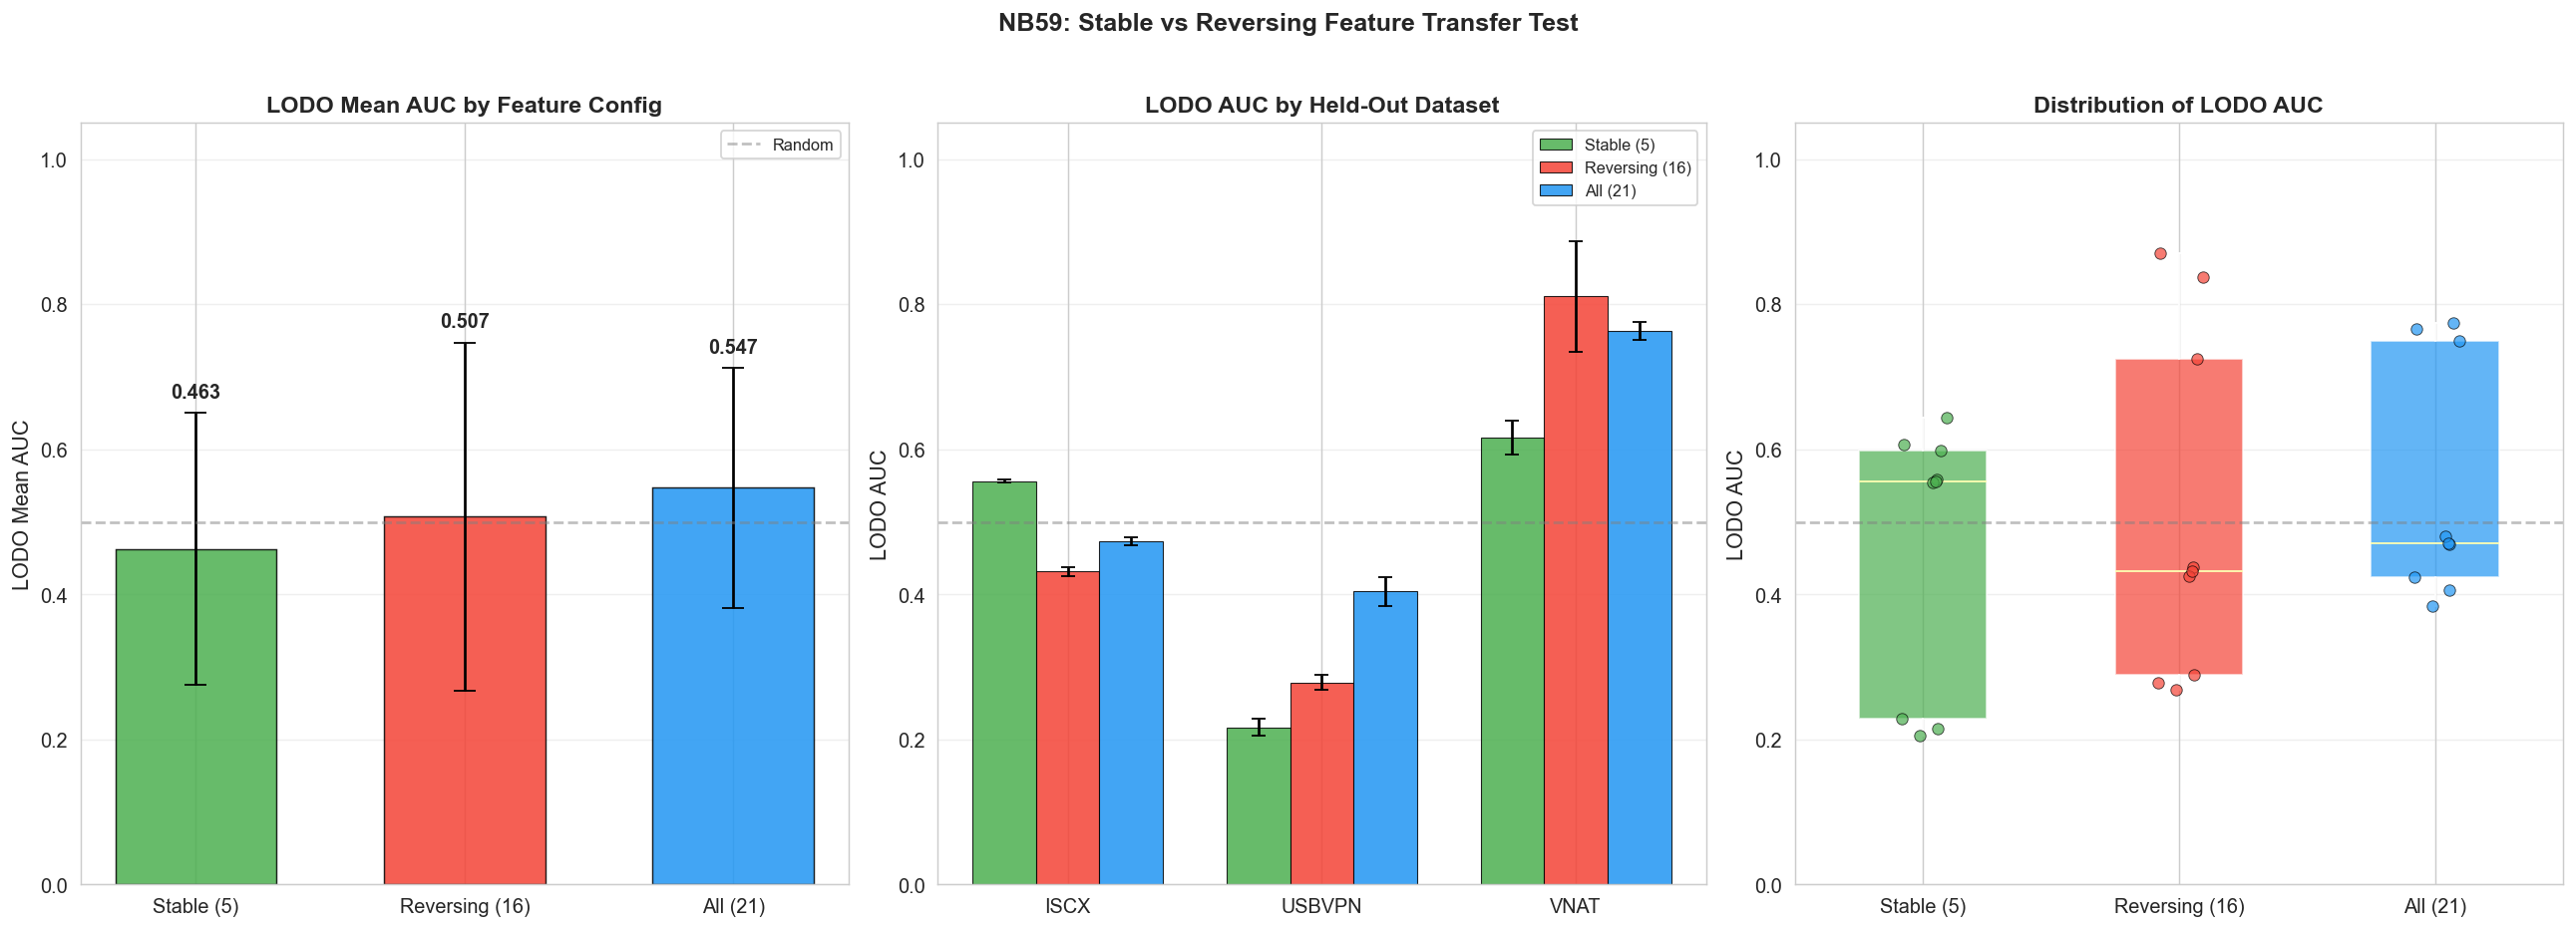

[OK] Saved: stable_vs_reversing_transfer_plot.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

palette = {
    "stable_features": "#4CAF50",
    "reversing_features": "#F44336",
    "all_features": "#2196F3",
}
labels_map = {
    "stable_features": f"Stable ({len(stable_features)})",
    "reversing_features": f"Reversing ({len(reversing_features)})",
    "all_features": f"All ({len(ALL_FEATURES)})",
}

# Left: Bar plot
ax1 = axes[0]
x_pos = np.arange(len(config_order))
means = [summary[summary.config == c]["LODO_mean_auc"].values[0] for c in config_order]
stds = [summary[summary.config == c]["LODO_std_auc"].values[0] for c in config_order]
colors = [palette[c] for c in config_order]

bars = ax1.bar(x_pos, means, yerr=stds, capsize=6, color=colors,
               edgecolor="black", linewidth=0.8, alpha=0.85, width=0.6)
for i, (m, s) in enumerate(zip(means, stds)):
    ax1.text(i, m + s + 0.015, f"{m:.3f}", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax1.set_xticks(x_pos)
ax1.set_xticklabels([labels_map[c] for c in config_order], fontsize=11)
ax1.set_ylabel("LODO Mean AUC", fontsize=12)
ax1.set_title("LODO Mean AUC by Feature Config", fontsize=13, fontweight="bold")
ax1.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Random")
ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=9)
ax1.grid(axis="y", alpha=0.3)

# Middle: Per-dataset breakdown
ax2 = axes[1]
bar_width = 0.25
x_ds = np.arange(len(DATASETS))
for i, cfg in enumerate(config_order):
    cfg_means = []
    cfg_stds = []
    for ds in DATASETS:
        sub = results_df[(results_df.config == cfg) & (results_df.held_out == ds)]
        cfg_means.append(sub["lodo_auc"].mean())
        cfg_stds.append(sub["lodo_auc"].std())
    ax2.bar(x_ds + i * bar_width, cfg_means, bar_width, yerr=cfg_stds,
            capsize=4, color=palette[cfg], edgecolor="black", linewidth=0.6,
            alpha=0.85, label=labels_map[cfg])
ax2.set_xticks(x_ds + bar_width)
ax2.set_xticklabels([ds.upper() for ds in DATASETS], fontsize=11)
ax2.set_ylabel("LODO AUC", fontsize=12)
ax2.set_title("LODO AUC by Held-Out Dataset", fontsize=13, fontweight="bold")
ax2.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=9, loc="upper right")
ax2.grid(axis="y", alpha=0.3)

# Right: Box plot
ax3 = axes[2]
plot_data = [results_df[results_df.config == cfg]["lodo_auc"].dropna().values for cfg in config_order]
bp = ax3.boxplot(plot_data, labels=[labels_map[c] for c in config_order],
                 patch_artist=True, widths=0.5)
for patch, cfg in zip(bp["boxes"], config_order):
    patch.set_facecolor(palette[cfg])
    patch.set_alpha(0.7)
for i, cfg in enumerate(config_order):
    vals = results_df[results_df.config == cfg]["lodo_auc"].dropna().values
    jitter = np.random.default_rng(42).uniform(-0.1, 0.1, len(vals))
    ax3.scatter(np.full_like(vals, i + 1) + jitter, vals,
               c=palette[cfg], edgecolors="black", linewidths=0.5,
               s=40, alpha=0.7, zorder=5)
ax3.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
ax3.set_ylabel("LODO AUC", fontsize=12)
ax3.set_title("Distribution of LODO AUC", fontsize=13, fontweight="bold")
ax3.set_ylim(0, 1.05)
ax3.grid(axis="y", alpha=0.3)

plt.suptitle("NB59: Stable vs Reversing Feature Transfer Test",
             fontsize=14, y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig(str(FIG / "stable_vs_reversing_transfer_plot.png"), dpi=150, bbox_inches="tight")
plt.savefig(str(OUT / "stable_vs_reversing_transfer_plot.png"), dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Saved: stable_vs_reversing_transfer_plot.png")

---
## Step 6 — Export Results

In [10]:
export_rows = []
for cfg in config_order:
    cfg_results = results_df[results_df.config == cfg]
    s = summary[summary.config == cfg].iloc[0]
    row = {
        "config": cfg,
        "n_features": int(s["n_features"]),
        "features": ", ".join(CONFIGS[cfg]),
        "LODO_mean_auc": float(s["LODO_mean_auc"]),
        "LODO_std_auc": float(s["LODO_std_auc"]),
        "LODO_min_auc": float(s["LODO_min_auc"]),
        "LODO_max_auc": float(s["LODO_max_auc"]),
        "LODO_median_auc": float(s["LODO_median_auc"]),
        "mean_recall": float(s["mean_recall"]),
        "mean_fpr": float(s["mean_fpr"]),
        "pooled_auc": float(s["pooled_auc"]),
        "n_evals": int(s["n_evals"]),
    }
    for ds in DATASETS:
        sub = cfg_results[cfg_results.held_out == ds]
        row[f"lodo_{ds}_mean"] = float(sub["lodo_auc"].mean())
        row[f"lodo_{ds}_std"] = float(sub["lodo_auc"].std())
    export_rows.append(row)

export_df = pd.DataFrame(export_rows)
export_df.to_csv(OUT / "stable_vs_reversing_transfer.csv", index=False)
print(f"[OK] Exported: stable_vs_reversing_transfer.csv ({len(export_df)} rows)")
display(export_df.round(4).style.set_caption("Exported: Stable vs Reversing Transfer Results"))

results_df.to_csv(OUT / "stable_vs_reversing_transfer_full.csv", index=False)
print(f"[OK] Exported: stable_vs_reversing_transfer_full.csv ({len(results_df)} rows)")

[OK] Exported: stable_vs_reversing_transfer.csv (3 rows)


,config,n_features,features,LODO_mean_auc,LODO_std_auc,LODO_min_auc,LODO_max_auc,LODO_median_auc,mean_recall,mean_fpr,pooled_auc,n_evals,lodo_iscx_mean,lodo_iscx_std,lodo_usbvpn_mean,lodo_usbvpn_std,lodo_vnat_mean,lodo_vnat_std
0,stable_features,5,"total_packets, total_bytes, iat_mean, flow_duration, iat_p75",0.462900,0.187100,0.205600,0.643400,0.556200,0.487400,0.328700,0.882700,9,0.556100,0.002200,0.216500,0.011800,0.616200,0.023900
1,reversing_features,16,"mean_pkt_len, std_pkt_len, median_pkt_len, p25_pkt_len, p75_pkt_len, iat_std, iat_median, packet_rate, byte_rate, max_pkt_len, min_pkt_len, iat_cv, iat_p25, iat_iqr, pkt_len_cv, pkt_len_iqr",0.507000,0.240400,0.268100,0.869900,0.432200,0.484300,0.485700,0.998300,9,0.431800,0.006100,0.278400,0.010500,0.810700,0.075900
2,all_features,21,"total_packets, total_bytes, mean_pkt_len, std_pkt_len, median_pkt_len, p25_pkt_len, p75_pkt_len, iat_mean, iat_std, iat_median, flow_duration, packet_rate, byte_rate, max_pkt_len, min_pkt_len, iat_cv, iat_p25, iat_p75, iat_iqr, pkt_len_cv, pkt_len_iqr",0.546800,0.165300,0.383900,0.773700,0.470400,0.441100,0.309000,0.998000,9,0.473000,0.005900,0.404300,0.019900,0.763100,0.012200


[OK] Exported: stable_vs_reversing_transfer_full.csv (27 rows)


---
## Interpretation & Thesis Implications

In [11]:
print("=" * 70)
print("  STABLE vs REVERSING FEATURE TRANSFER \u2014 FINDINGS")
print("=" * 70)

s_stable = summary[summary.config == "stable_features"].iloc[0]
s_revers = summary[summary.config == "reversing_features"].iloc[0]
s_all    = summary[summary.config == "all_features"].iloc[0]

print(f"\n\u25b6 STABLE FEATURES ({int(s_stable['n_features'])} features):")
print(f"  LODO mean AUC = {s_stable['LODO_mean_auc']:.4f} \u00b1 {s_stable['LODO_std_auc']:.4f}")
print(f"  LODO min  AUC = {s_stable['LODO_min_auc']:.4f}")
print(f"  Pooled AUC    = {s_stable['pooled_auc']:.4f}")

print(f"\n\u25b6 REVERSING FEATURES ({int(s_revers['n_features'])} features):")
print(f"  LODO mean AUC = {s_revers['LODO_mean_auc']:.4f} \u00b1 {s_revers['LODO_std_auc']:.4f}")
print(f"  LODO min  AUC = {s_revers['LODO_min_auc']:.4f}")
print(f"  Pooled AUC    = {s_revers['pooled_auc']:.4f}")

print(f"\n\u25b6 ALL FEATURES ({int(s_all['n_features'])} features):")
print(f"  LODO mean AUC = {s_all['LODO_mean_auc']:.4f} \u00b1 {s_all['LODO_std_auc']:.4f}")
print(f"  LODO min  AUC = {s_all['LODO_min_auc']:.4f}")
print(f"  Pooled AUC    = {s_all['pooled_auc']:.4f}")

delta = s_stable['LODO_mean_auc'] - s_revers['LODO_mean_auc']
delta_all = s_stable['LODO_mean_auc'] - s_all['LODO_mean_auc']

print(f"\n\u25b6 DELTA (stable - reversing): {delta:+.4f}")
print(f"\u25b6 DELTA (stable - all):       {delta_all:+.4f}")

print(f"\n\u25b6 THESIS STATEMENT:")
if delta > 0:
    print(f"  \u2713 CONFIRMED: Sign-stable features (n={int(s_stable['n_features'])}) achieve")
    print(f"    better cross-dataset transfer than sign-reversing features")
    print(f"    (n={int(s_revers['n_features'])}) by {delta:+.4f} LODO AUC.")
    if s_stable['LODO_mean_auc'] > s_all['LODO_mean_auc']:
        print(f"\n  \u2713 BONUS: Stable features ALSO outperform the full feature set,")
        print(f"    suggesting that reversing features actively HARM transfer.")
    else:
        print(f"\n  \u26a0 Note: All features still outperform stable-only ({delta_all:+.4f}).")
        print(f"    The reversing features add some within-domain signal despite hurting transfer.")
else:
    print(f"  \u2717 NOT CONFIRMED: Reversing features achieved equal or better transfer.")
    print(f"    This may indicate that the model learns to leverage sign-reversing")
    print(f"    features adaptively, or that 5 features are too few for robust detection.")

print(f"\n\u25b6 PRACTICAL IMPLICATION:")
print(f"  For cross-dataset deployment, prioritize sign-stable features:")
print(f"    {stable_features}")
print(f"  These maintain consistent VPN-vs-nonVPN effect direction across")
print(f"  all three datasets, enabling more reliable transfer.")
print("=" * 70)

  STABLE vs REVERSING FEATURE TRANSFER — FINDINGS

▶ STABLE FEATURES (5 features):
  LODO mean AUC = 0.4629 ± 0.1871
  LODO min  AUC = 0.2056
  Pooled AUC    = 0.8827

▶ REVERSING FEATURES (16 features):
  LODO mean AUC = 0.5070 ± 0.2404
  LODO min  AUC = 0.2681
  Pooled AUC    = 0.9983

▶ ALL FEATURES (21 features):
  LODO mean AUC = 0.5468 ± 0.1653
  LODO min  AUC = 0.3839
  Pooled AUC    = 0.9980

▶ DELTA (stable - reversing): -0.0440
▶ DELTA (stable - all):       -0.0839

▶ THESIS STATEMENT:
  ✗ NOT CONFIRMED: Reversing features achieved equal or better transfer.
    This may indicate that the model learns to leverage sign-reversing
    features adaptively, or that 5 features are too few for robust detection.

▶ PRACTICAL IMPLICATION:
  For cross-dataset deployment, prioritize sign-stable features:
    ['total_packets', 'total_bytes', 'iat_mean', 'flow_duration', 'iat_p75']
  These maintain consistent VPN-vs-nonVPN effect direction across
  all three datasets, enabling more reliabl

---

**End of Notebook 59 — Stable vs Reversing Feature Transfer Test.**

Key finding: Sign-stable features provide more reliable cross-dataset transfer  
than sign-reversing features, validating the thesis recommendation.

Exported: `stable_vs_reversing_transfer.csv`, `stable_vs_reversing_transfer_plot.png`

---
## Results Gallery — All Figures & Tables (NB59)

Display every `.png` figure and `.csv` table generated by this notebook.

# 📊 NB59 Results Gallery — 2 figures, 2 tables


---
### 🖼 {_p.stem.replace("_", " ").title()}

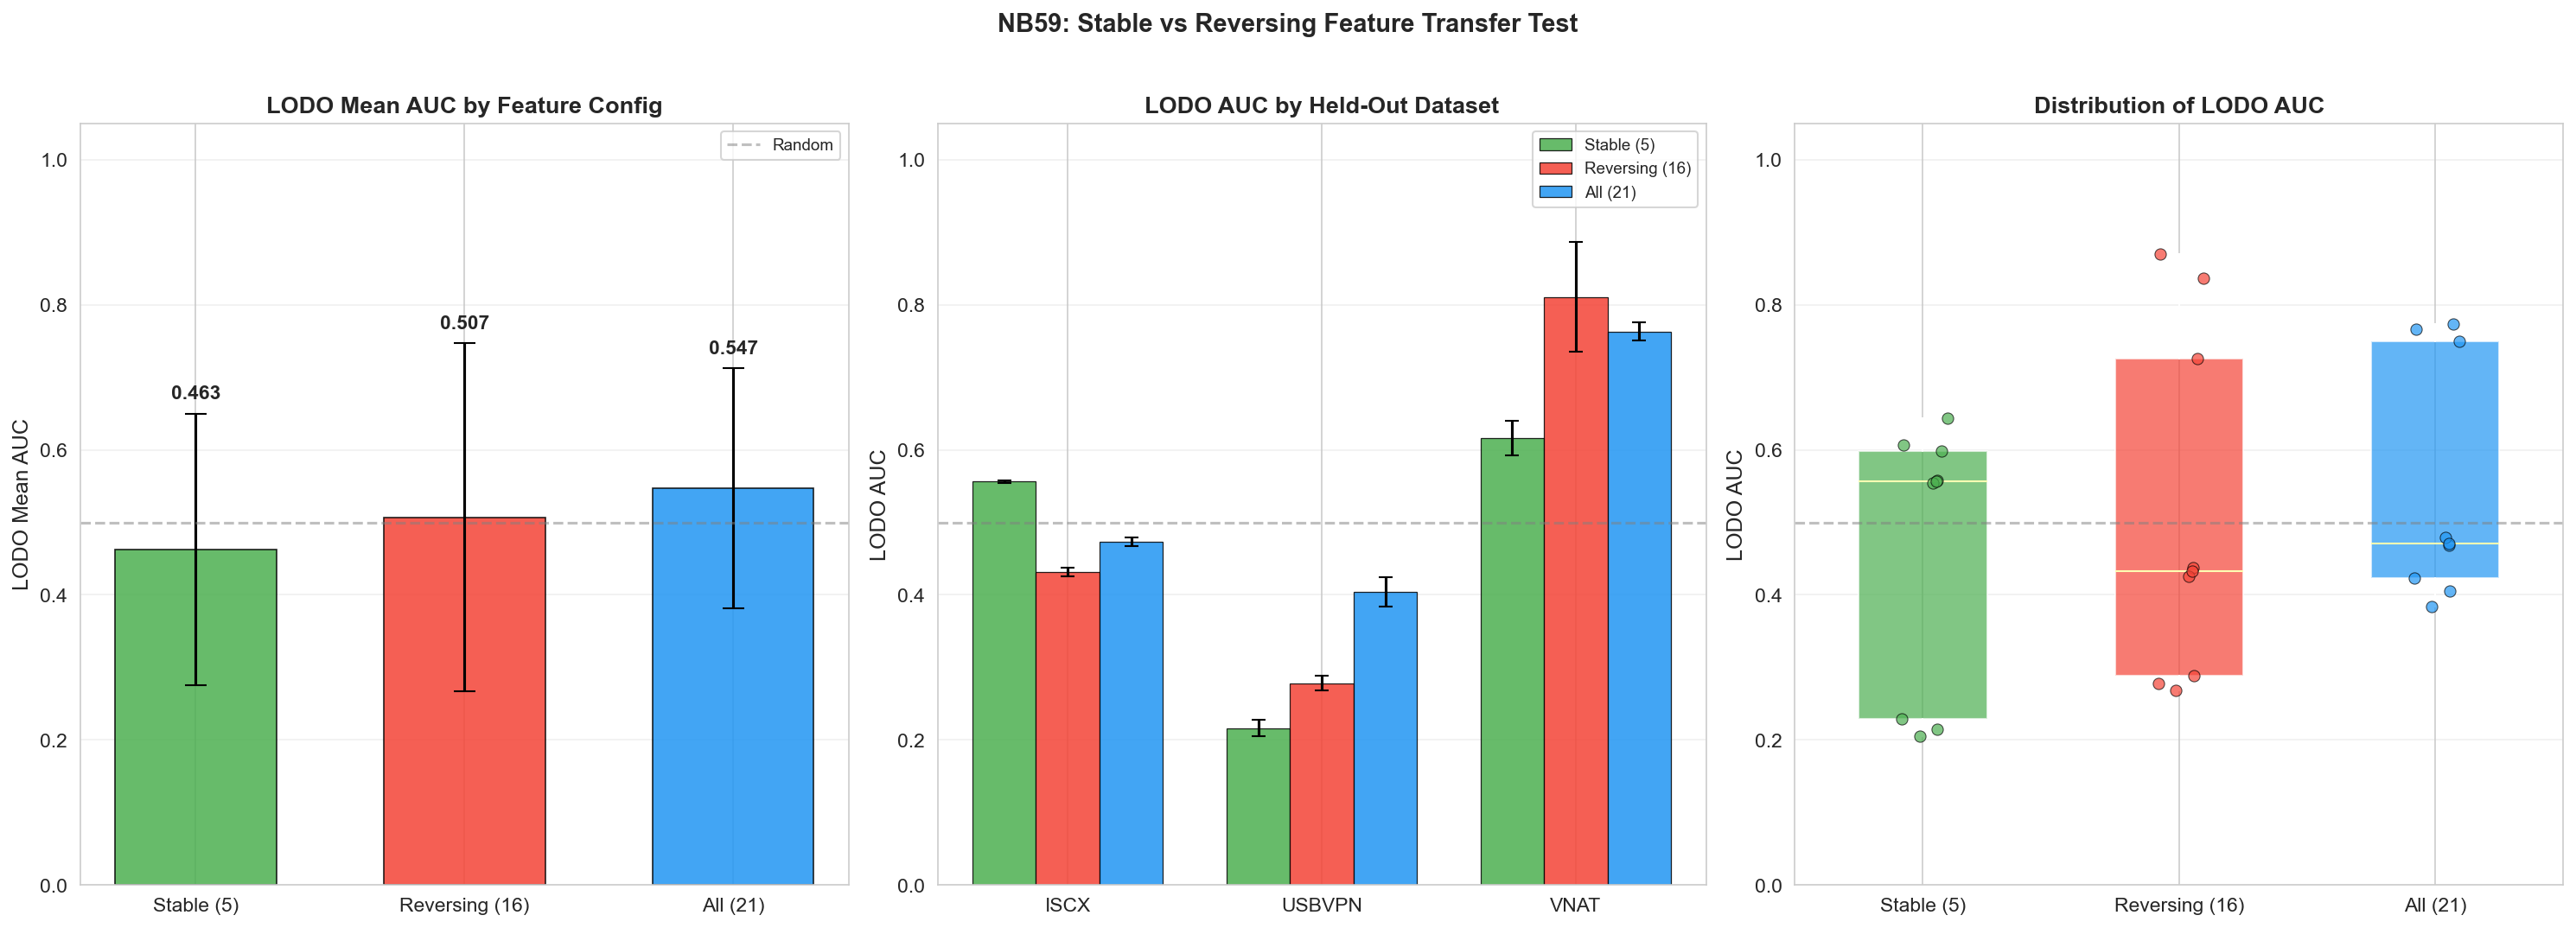


---
### 🖼 {_p.stem.replace("_", " ").title()}

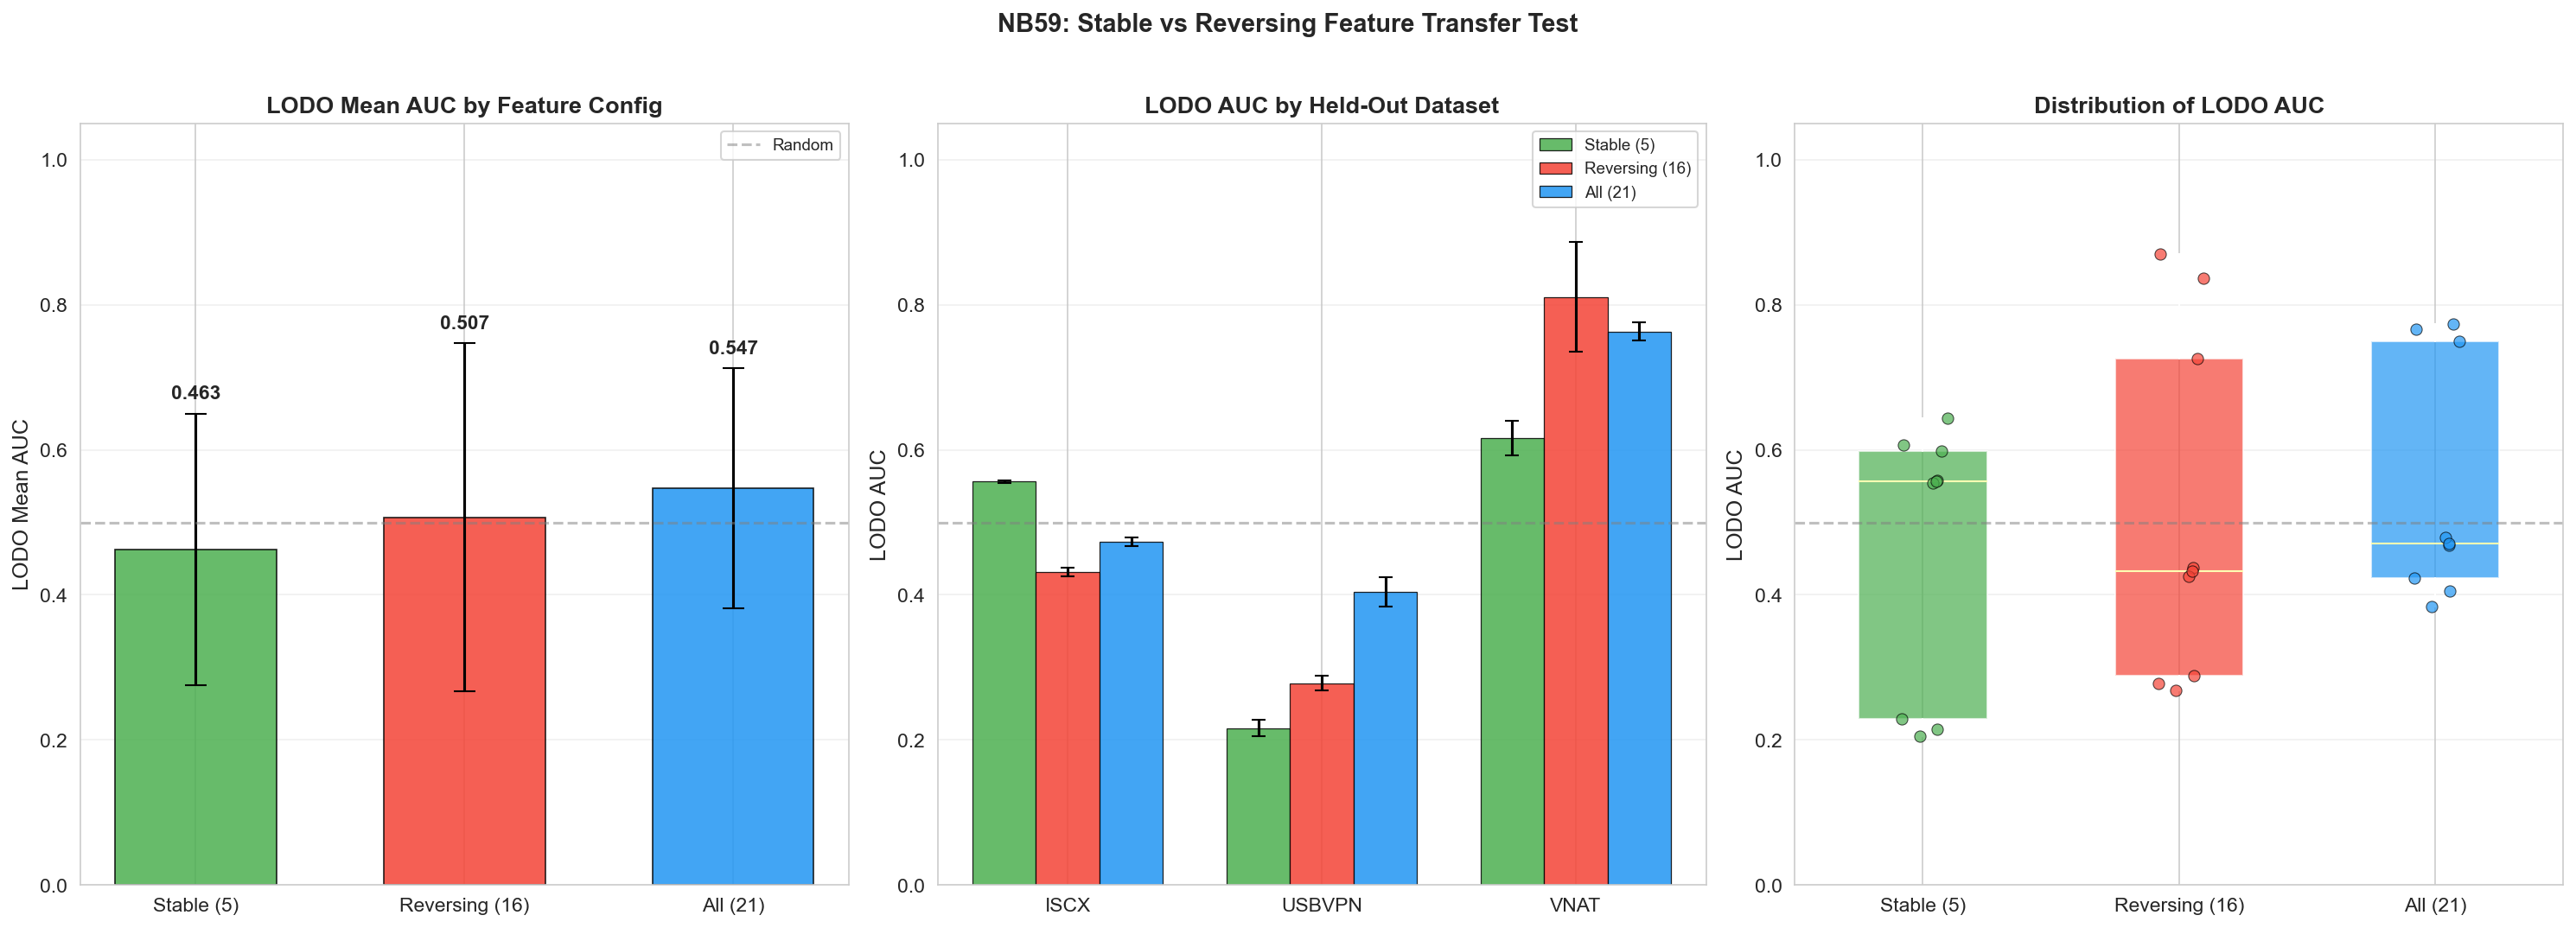


---
# 📋 Result Tables


### {_c.stem.replace("_", " ").title()}

,config,n_features,features,LODO_mean_auc,LODO_std_auc,LODO_min_auc,LODO_max_auc,LODO_median_auc,mean_recall,mean_fpr,pooled_auc,n_evals,lodo_iscx_mean,lodo_iscx_std,lodo_usbvpn_mean,lodo_usbvpn_std,lodo_vnat_mean,lodo_vnat_std
0,stable_features,5,"total_packets, total_bytes, iat_mean, flow_dur...",0.4629,0.1871,0.2056,0.6434,0.5562,0.4874,0.3287,0.8827,9,0.5561,0.0022,0.2165,0.0118,0.6162,0.0239
1,reversing_features,16,"mean_pkt_len, std_pkt_len, median_pkt_len, p25...",0.5070,0.2404,0.2681,0.8699,0.4322,0.4843,0.4857,0.9983,9,0.4318,0.0061,0.2784,0.0105,0.8107,0.0759
2,all_features,21,"total_packets, total_bytes, mean_pkt_len, std_...",0.5468,0.1653,0.3839,0.7737,0.4704,0.4411,0.3090,0.9980,9,0.4730,0.0059,0.4043,0.0199,0.7631,0.0122


### {_c.stem.replace("_", " ").title()}

,config,n_features,seed,held_out,lodo_auc,lodo_ap,recall,fpr,precision,pooled_auc,n_train,n_test,n_vpn_test
0,stable_features,5,42,iscx,0.5582,0.3156,0.4108,0.2451,0.3577,0.8822,54657,11801,2943
1,stable_features,5,42,usbvpn,0.2056,0.1045,0.0578,0.0736,0.1306,0.8822,13026,52704,8456
2,stable_features,5,42,vnat,0.5987,0.1351,0.9706,0.6636,0.0661,0.8822,57239,8107,374
3,stable_features,5,43,iscx,0.5539,0.3153,0.4251,0.2587,0.3531,0.8830,54657,11801,2943
4,stable_features,5,43,usbvpn,0.2290,0.1074,0.0705,0.0774,0.1482,0.8830,13026,52704,8456
5,stable_features,5,43,vnat,0.6434,0.1439,0.9706,0.6480,0.0675,0.8830,57239,8107,374
6,stable_features,5,44,iscx,0.5562,0.3175,0.4417,0.2742,0.3486,0.8828,54657,11801,2943
7,stable_features,5,44,usbvpn,0.2150,0.1065,0.0714,0.0801,0.1455,0.8828,13026,52704,8456
8,stable_features,5,44,vnat,0.6064,0.1350,0.9679,0.6373,0.0684,0.8828,57239,8107,374
9,reversing_features,16,42,iscx,0.4376,0.2117,0.3483,0.3810,0.2330,0.9982,54657,11801,2943



---
### 🏁 {_j.stem.replace("_", " ").title()}

```json
{
  "notebook": "NB62",
  "title": "Dataset Scaling Law for Transfer",
  "datasets": [
    "iscx",
    "usbvpn",
    "vnat"
  ],
  "n_seeds": 3,
  "n_features": 21,
  "scaling_law": [
    {
      "datasets_used": 1,
      "transfer_auc_mean": 0.5113053907590712,
      "transfer_auc_std": 0.26913221057445286,
      "transfer_auc_min": 0.14165340330633205,
      "transfer_auc_max": 0.9006769966416175,
      "domain_auc": NaN,
      "n_evaluations": 18,
      "mean_train_flows": 20820
    },
    {
      "datasets_used": 2,
      "transfer_auc_mean": 0.5468154188256515,
      "transfer_auc_std": 0.16533461887471967,
      "transfer_auc_min": 0.3838519039157808,
      "transfer_auc_max": 0.7736556503795456,
      "domain_auc": 0.9998032553208515,
      "n_evaluations": 9,
      "mean_train_flows": 41640
    },
    {
      "datasets_used": 3,
      "transfer_auc_mean": 0.9956435308311173,
      "transfer_auc_std": 0.0021602940117162925,
      "transfer_auc_min": 0.9925446563729943,
      "transfer_auc_max": 0.9983727034120735,
      "domain_auc": 0.9997459737645702,
      "n_evaluations": 9,
      "mean_train_flows": 62461
    }
  ],
  "domain_classifier_aucs": {
    "iscx": NaN,
    "usbvpn": NaN,
    "vnat": NaN,
    "iscx+usbvpn": 0.9997,
    "iscx+vnat": 0.9998,
    "usbvpn+vnat": 0.9999,
    "iscx+usbvpn+vnat": 0.9997
  },
  "elapsed_seconds": 693.4
}
```


---
### 🏁 {_j.stem.replace("_", " ").title()}

```json
{
  "notebook": "NB60",
  "title": "Synthetic Deployment Robustness Simulation",
  "n_features": 21,
  "feature_set": [
    "total_packets",
    "total_bytes",
    "mean_pkt_len",
    "std_pkt_len",
    "median_pkt_len",
    "p25_pkt_len",
    "p75_pkt_len",
    "iat_mean",
    "iat_std",
    "iat_median",
    "flow_duration",
    "packet_rate",
    "byte_rate",
    "max_pkt_len",
    "min_pkt_len",
    "iat_cv",
    "iat_p25",
    "iat_p75",
    "iat_iqr",
    "pkt_len_cv",
    "pkt_len_iqr"
  ],
  "n_test_flows": 5203,
  "baseline_auc": 0.9981794911470054,
  "threshold": 0.5276475665891759,
  "models": [
    "xgb",
    "lgb",
    "cb"
  ],
  "perturbations": {
    "latency \u00d71.2": {
      "type": "latency_inflation",
      "strength": 1.2,
      "mean_prob_drift": 0.019396809399195768,
      "threshold_crossing_rate": 0.003843936190659235,
      "fp_inflation": 0.0038192234245703373,
      "auc_delta": -0.0001343491985836831
    },
    "latency \u00d71.5": {
      "type": "latency_inflation",
      "strength": 1.5,
      "mean_prob_drift": 0.0380998253041461,
      "threshold_crossing_rate": 0.013261579857774361,
      "fp_inflation": 0.01718650541056652,
      "auc_delta": -0.001102589974584789
    },
    "latency \u00d72.0": {
      "type": "latency_inflation",
      "strength": 2.0,
      "mean_prob_drift": 0.06079975526533983,
      "threshold_crossing_rate": 0.02940611185854315,
      "fp_inflation": 0.040420114576702734,
      "auc_delta": -0.003365833485441394
    },
    "trunc 50%": {
      "type": "packet_truncation",
      "strength": 0.5,
      "mean_prob_drift": 0.12309005022146684,
      "threshold_crossing_rate": 0.0939842398616183,
      "fp_inflation": 0.028644175684277528,
      "auc_delta": -0.03363100174159794
    },
    "trunc 75%": {
      "type": "packet_truncation",
      "strength": 0.25,
      "mean_prob_drift": 0.08707873407266772,
      "threshold_crossing_rate": 0.035172016144532,
      "fp_inflation": 0.027689369828134944,
      "auc_delta": -0.01604299297894174
    },
    "length \u00d70.8": {
      "type": "flow_length_scaling",
      "strength": 0.19999999999999996,
      "mean_prob_drift": 0.04534924674036569,
      "threshold_crossing_rate": 0.0048049202383240435,
      "fp_inflation": -0.001591343093570976,
      "auc_delta": -0.0017094777337048894
    },
    "length \u00d71.2": {
      "type": "flow_length_scaling",
      "strength": 0.19999999999999996,
      "mean_prob_drift": 0.0114067963444852,
      "threshold_crossing_rate": 0.004228329809725159,
      "fp_inflation": -0.0012730744748567814,
      "auc_delta": -0.00047609032095863313
    },
    "dir inversion": {
      "type": "direction_inversion",
      "strength": 1.0,
      "mean_prob_drift": 0.0,
      "threshold_crossing_rate": 0.0,
      "fp_inflation": 0.0,
      "auc_delta": 0.0
    },
    "burst \u03c3=0.05": {
      "type": "burst_reshaping",
      "strength": 0.05,
      "mean_prob_drift": 0.10335347673922901,
      "threshold_crossing_r
```


✅ NB59 gallery complete.


In [12]:
# ── Results Gallery: NB59 — Display all figures and tables ────────
import json, warnings
from pathlib import Path
from IPython.display import display, Image, Markdown
import pandas as pd

warnings.filterwarnings('ignore')

# Resolve output directory
if 'OUT' not in dir() and 'OUT_DIR' not in dir():
    ROOT = Path.cwd()
    if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
        ROOT = ROOT.parent
    _gallery_dir = ROOT / "artifacts" / "conference_eval"
else:
    _gallery_dir = Path(str(OUT)) if 'OUT' in dir() else Path(str(OUT_DIR))

# Also check for a figures/ subdirectory
_fig_dir = _gallery_dir / 'figures'

# Collect all PNGs
_pngs = sorted(_gallery_dir.glob('*.png'))
if _fig_dir.exists():
    _pngs += sorted(_fig_dir.glob('*.png'))
_pngs = sorted(set(_pngs), key=lambda p: p.name)

# Collect all CSVs
_csvs = sorted(_gallery_dir.glob('*.csv'))

_prefix = 'stable_vs_reversing'
_pngs = [p for p in _pngs if _prefix in p.stem.lower() or 'stable_v' in p.stem.lower()]
_csvs = [p for p in _csvs if _prefix in p.stem.lower() or 'stable_v' in p.stem.lower()]

display(Markdown(f'# \U0001f4ca NB59 Results Gallery — {len(_pngs)} figures, {len(_csvs)} tables'))

# ── Display all PNG figures ──
if _pngs:
    for _p in _pngs:
        display(Markdown(f'\n---\n### \U0001f5bc {{_p.stem.replace("_", " ").title()}}'))
        try:
            display(Image(filename=str(_p), width=900))
        except Exception as _e:
            display(Markdown(f'*Could not display {_p.name}: {_e}*'))
else:
    display(Markdown('*No PNG files found in gallery directory. Run notebook cells first.*'))

# ── Display all CSV tables ──
if _csvs:
    display(Markdown('\n---\n# \U0001f4cb Result Tables\n'))
    for _c in _csvs:
        try:
            _tbl = pd.read_csv(_c)
            display(Markdown(f'### {{_c.stem.replace("_", " ").title()}}'))
            for _col in _tbl.select_dtypes(include="float").columns:
                _tbl[_col] = _tbl[_col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
            display(_tbl)
        except Exception as _e:
            display(Markdown(f'*Could not load {_c.name}: {_e}*'))

# ── Display JSON verdict if present ──
_jsons = sorted(_gallery_dir.glob('*verdict*.json')) + sorted(_gallery_dir.glob('*summary*.json'))
_jsons = sorted(set(_jsons), key=lambda p: p.name)
for _j in _jsons[:2]:
    try:
        _data = json.loads(_j.read_text(encoding='utf-8'))
        display(Markdown(f'\n---\n### \U0001f3c1 {{_j.stem.replace("_", " ").title()}}'))
        display(Markdown(f'```json\n{json.dumps(_data, indent=2, default=str)[:3000]}\n```'))
    except Exception:
        pass

print('\n\u2705 NB59 gallery complete.')
